In [1]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import sem
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
import netCDF4
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot

In [3]:
abiotic_data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola/abiotic_data/'

In [5]:
start_date = '2022-08-01T00:00:00'
end_date = '2023-03-31T00:00:00'

hobo_temp_data = pd.read_csv(abiotic_data_path + 'cleaned_rockaway_hobo_logger.csv')

hobo_temp_data['date_time'] = pd.to_datetime(hobo_temp_data['datetime'])
hobo_temp_data = hobo_temp_data[(hobo_temp_data['date_time'] > start_date) & (hobo_temp_data['date_time'] <= end_date)]
hobo_dateday = hobo_temp_data['date']
hobo_time = hobo_temp_data['time']
hobo_date = hobo_temp_data['date_time']
hobo_temp = hobo_temp_data['temp(c)']

star_oddi_data = pd.read_csv(abiotic_data_path + 'cleaned_rockaway_star_oddi_salinity_data.csv')

star_oddi_data['date_time'] = pd.to_datetime(star_oddi_data['datetime'])
star_oddi_data = star_oddi_data[(star_oddi_data['date_time'] > start_date) & (star_oddi_data['date_time'] <= end_date)]
star_oddi_data = star_oddi_data[star_oddi_data['salinity(ppt)'] > 5]
star_salinity = star_oddi_data['salinity(ppt)']
star_conduct = star_oddi_data['conduct(mS/cm)']
star_velocity = star_oddi_data['velocity(m/sec)']
star_dateday = star_oddi_data['date']
star_time = star_oddi_data['time']
star_date = star_oddi_data['date_time']
star_temp = star_oddi_data['temp(c)']

fp_daily_data = pd.read_csv(abiotic_data_path + 'fort_point_salinity_daily.csv')
fp_daily_data['date_time'] = pd.to_datetime(fp_daily_data['datetime'])
fp_daily_date = fp_daily_data['date_time']
fp_daily_salinity = fp_daily_data['salinity(ppt)']

fp_hourly_data = pd.read_csv(abiotic_data_path + 'fort_point_salinity_hourly.csv')
fp_hourly_data['date_time'] = pd.to_datetime(fp_hourly_data['datetime'])
fp_hourly_date = fp_hourly_data['date_time']
fp_hourly_salinity = fp_hourly_data['salinity(ppt)']

precip_data = pd.read_csv(abiotic_data_path +'precipitation.csv')

precip_data['date_time'] = pd.to_datetime(precip_data['datetime'])
precip_data = precip_data[(precip_data['date_time'] > start_date) & (precip_data['date_time'] <= end_date)]
precip_date = precip_data['date_time']
precip_rain = precip_data['rain(mm)']

In [ ]:
algae_fp_seven_hr = pd.merge(final_algae_data, fp_hourly_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
algae_fp_seven_hr['seven_day_salinity'] = None

for index, row in algae_fp_seven_hr.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=7)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    algae_seven_subset_fp_hr = fp_hourly_data[(fp_hourly_data['date_time'] >= start_date) & (fp_hourly_data['date_time'] <= end_date)]
    #print('start date:', start_date, 'end date:', end_date)
    # Calculate the average salinity
    algae_average_salinity_fp_hr = algae_seven_subset_fp_hr['salinity(ppt)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    algae_fp_seven_hr.at[index, 'seven_day_salinity'] = algae_average_salinity_fp_hr

algae_star_seven = pd.merge(final_algae_data, star_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
algae_star_seven['seven_day_salinity'] = None
algae_star_seven['seven_day_temp'] = None

for index, row in algae_star_seven.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=7)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    algae_seven_subset = star_data[(star_data['date_time'] >= start_date) & (star_data['date_time'] <= end_date)]

    # Calculate the average salinity
    algae_average_salinity = algae_seven_subset['salinity(ppt)'].mean()
    algae_average_temp = algae_seven_subset['temp(c)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    algae_star_seven.at[index, 'seven_day_salinity'] = algae_average_salinity
    algae_star_seven.at[index, 'seven_day_temp'] = algae_average_temp

    #algae_star_seven['seven_day_salinity'].fillna(method='ffill', inplace=True)
    #algae_star_seven['seven_day_temp'].fillna(method='ffill', inplace=True)
    #print('start date:', start_date, 'end date:', end_date)
    #print(algae_average_salinity)

chlor_star_seven = pd.merge(final_chl_data, star_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
chlor_star_seven['seven_day_salinity'] = None
chlor_star_seven['seven_day_temp'] = None

for index, row in chlor_star_seven.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=7)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    chlor_seven_subset = star_data[(star_data['date_time'] >= start_date) & (star_data['date_time'] <= end_date)]

    # Calculate the average salinity
    chlor_average_salinity = chlor_seven_subset['salinity(ppt)'].mean()
    chlor_average_temp = chlor_seven_subset['temp(c)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    chlor_star_seven.at[index, 'seven_day_salinity'] = chlor_average_salinity
    chlor_star_seven.at[index, 'seven_day_temp'] = chlor_average_temp

    #chlor_star_seven['seven_day_salinity'].fillna(method='ffill', inplace=True)
    #chlor_star_seven['seven_day_temp'].fillna(method='ffill', inplace=True)

algae_hobo_seven = pd.merge(final_algae_data, hobo_data, on='date_time', how='left')

# Assign the average temp for each biological data entry
algae_hobo_seven['seven_day_temp'] = None

for index, row in algae_hobo_seven.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=7)
    end_date = collection_date - timedelta(days=0)

    # Filter temp data within the date range
    algae_seven_subset_hobo = hobo_data[(hobo_data['date_time'] >= start_date) & (hobo_data['date_time'] <= end_date)]

    # Calculate the average temperature
    algae_average_temp_hobo = algae_seven_subset_hobo['temp(c)'].mean()

    # Assign the average temp to the corresponding row in merged_data
    algae_hobo_seven.at[index, 'seven_day_temp'] = algae_average_temp_hobo

    #algae_hobo_seven['seven_day_temp'].fillna(method='ffill', inplace=True)
    #print('start date:', start_date, 'end date:', end_date)
    #print(algae_average_temp_hobo)

chlor_hobo_seven = pd.merge(final_chl_data, hobo_data, on='date_time', how='left')

# Assign the average temp for each biological data entry
chlor_hobo_seven['seven_day_temp'] = None

for index, row in chlor_hobo_seven.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=7)
    end_date = collection_date - timedelta(days=0)

    # Filter temp data within the date range
    chlor_seven_subset_hobo = hobo_data[(hobo_data['date_time'] >= start_date) & (hobo_data['date_time'] <= end_date)]

    # Calculate the average temp
    chlor_average_temp_hobo = chlor_seven_subset_hobo['temp(c)'].mean()

    # Assign the average temp to the corresponding row in merged_data
    chlor_hobo_seven.at[index, 'seven_day_temp'] = chlor_average_temp_hobo

    #chlor_hobo_seven['seven_day_temp'].fillna(method='ffill', inplace=True)

In [ ]:
algae_star_fourteen = pd.merge(final_algae_data, star_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
algae_star_fourteen['fourteen_day_salinity'] = None
algae_star_fourteen['fourteen_day_temp'] = None

for index, row in algae_star_fourteen.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=14)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    algae_fourteen_subset = star_data[(star_data['date_time'] >= start_date) & (star_data['date_time'] <= end_date)]

    # Calculate the average salinity
    algae_average_salinity_fourteen = algae_fourteen_subset['salinity(ppt)'].mean()
    algae_average_temp_fourteen = algae_fourteen_subset['temp(c)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    algae_star_fourteen.at[index, 'fourteen_day_salinity'] = algae_average_salinity_fourteen
    algae_star_fourteen.at[index, 'fourteen_day_temp'] = algae_average_temp_fourteen

algae_star_three= pd.merge(final_algae_data, star_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
algae_star_three['three_day_salinity'] = None
algae_star_three['three_day_temp'] = None

for index, row in algae_star_three.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=3)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    algae_three_subset = star_data[(star_data['date_time'] >= start_date) & (star_data['date_time'] <= end_date)]

    # Calculate the average salinity
    algae_average_salinity_three = algae_three_subset['salinity(ppt)'].mean()
    algae_average_temp_three = algae_three_subset['temp(c)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    algae_star_three.at[index, 'three_day_salinity'] = algae_average_salinity_three
    algae_star_three.at[index, 'three_day_temp'] = algae_average_temp_three


chlor_star_fourteen = pd.merge(final_chl_data, star_data, on='date_time', how='left')

# Assign the average salinity for each biological data entry
chlor_star_fourteen['fourteen_day_salinity'] = None
chlor_star_fourteen['fourteen_day_temp'] = None

for index, row in chlor_star_fourteen.iterrows():
    collection_date = row['date_time']
    start_date = collection_date - timedelta(days=14)
    end_date = collection_date - timedelta(days=0)

    # Filter salinity data within the date range
    chlor_fourteen_subset = star_data[(star_data['date_time'] >= start_date) & (star_data['date_time'] <= end_date)]

    # Calculate the average salinity
    chlor_fourteen_salinity = chlor_fourteen_subset['salinity(ppt)'].mean()
    chlor_fourteen_temp = chlor_fourteen_subset['temp(c)'].mean()

    # Assign the average salinity to the corresponding row in merged_data
    chlor_star_fourteen.at[index, 'fourteen_day_salinity'] = chlor_fourteen_salinity
    chlor_star_fourteen.at[index, 'fourteen_day_temp'] = chlor_fourteen_temp


In [ ]:
#algae_star = pd.merge(final_algae_data, star_data, on='date_time')
#algae_daily_fp = pd.merge(final_algae_data, fp_daily_data, on='date_time')
#algae_hourly_fp = pd.merge(final_algae_data, fp_hourly_data, on='date_time')

#chlor_star = pd.merge(final_chl_data, star_data, on='date_time')
#chlor_daily_fp = pd.merge(final_chl_data, fp_daily_data, on='date_time')

#algae_hobo = pd.merge(final_algae_data, hobo_data, on='date_time')
#chlor_hobo = pd.merge(final_chl_data, hobo_data, on='date_time')

star_average = star_data.resample('D', on='date_time').mean().reset_index()
star_min = star_data.resample('D', on='date_time').min().reset_index()

hobo_average = hobo_data.resample('D', on='date_time').mean().reset_index()
hobo_min = hobo_data.resample('D', on='date_time').min().reset_index()

fp_average = fp_hourly_data.resample('D', on='date_time').mean().reset_index()
fp_min = fp_hourly_data.resample('D', on='date_time').min().reset_index()

algae_star_average = pd.merge(final_algae_data, star_average, on='date_time')
chlor_star_average = pd.merge(final_chl_data, star_average, on='date_time')
algae_star_min = pd.merge(final_algae_data, star_min, on='date_time')
chlor_star_min = pd.merge(final_chl_data, star_min, on='date_time')

algae_hobo_average = pd.merge(final_algae_data, hobo_average, on='date_time')
chlor_hobo_average = pd.merge(final_chl_data, hobo_average, on='date_time')
algae_hobo_min = pd.merge(final_algae_data, hobo_min, on='date_time')
chlor_hobo_min = pd.merge(final_chl_data, hobo_min, on='date_time')

In [ ]:
display(star_average)

,date_time,temp(c),salinity(ppt),conduct(mS/cm),velocity(m/sec),Unnamed: 7,Unnamed: 8
0,2022-08-13,16.800000,30.897083,39.966667,1507.426042,NaN,NaN
1,2022-08-14,16.125909,30.723788,39.173030,1505.144394,NaN,NaN
2,2022-08-15,14.861667,30.201111,37.477639,1500.527500,NaN,NaN
3,2022-08-16,14.451389,31.308333,38.352222,1500.504722,NaN,NaN
4,2022-08-17,14.900694,31.855139,39.352361,1502.639583,NaN,NaN
...,...,...,...,...,...,...,...
226,2023-03-27,11.927361,23.617222,27.917361,1482.713194,NaN,NaN
227,2023-03-28,11.758451,28.271831,32.770986,1487.788169,NaN,NaN
228,2023-03-29,11.198485,26.290758,30.209848,1483.380152,NaN,NaN
229,2023-03-30,11.489444,23.677361,27.702778,1481.231806,NaN,NaN


# Setting up to retrieve satellite data

In [ ]:
#@title
print('netcdf4-python version: %s'%netCDF4.__version__)

In [ ]:
#@title
site_dict = {'ap': {'name' : 'Aramai Point',
        'lon' : -122.500725,
        'lat' : 37.607919,
        'Location' : 'Pacifica, San Mateo County, CA',
        'Site Description' : 'Aramai Point was originally named Rockaway Beach but has since been renamed to honor the Native American tribe that lived in the area for thousands of years. This public beach has hiking trails leading to prominent headlands that overshadow a rocky intertidal habitat below. The intertidal zone is very accessible, beginning a few hundred yards from the parking lot. Anemones, sea stars, tunicates, barnacles, and many other inverts are found throughout this site. Aramai Point is heavily trafficed by surfers, fishermen, and families, especially on the weekends.',
        'Research Conducted' : 'Identifying the impact intertidal positioning has on the symbiotic relationship between Anthopleura sola and their algal photosynthesizers.',
        'Student Researchers' : 'Jesse Espinoza'}
             }

In [ ]:
#@title
stns = list(site_dict.keys())
print('Cohen field station keys:', stns)

Cohen field station keys: ['ap']


# Create lists of all lat and lon values

* Make empty lists that hold desired values
* Make a loop that goes through each station and holds its coordinate values


---



In [ ]:
lats = []
lons = []
for stn in stns:
    lats.append(site_dict[stn]['lat']) #Filling up the latitude list by looping through our list of stations
    lons.append(site_dict[stn]['lon']) #Same but for longitude

print(lats)
print(lons)

[37.607919]
[-122.500725]


In [ ]:
start_time = '2022-08-27T12:00:00'
end_time = '2023-04-22T12:00:00'

## Making variables to hold the URL's we are pointing at

---



In [ ]:
#@title
mur_anom_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anom1day'
mur_sst_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41'

mur_anom_month_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anommday'
mur_sst_month__url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday'

# In case someone wants to look at upwelling data
upwell_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdQBstress3day_LonPM180'
#https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo_LonPM180.html

## Open a pointer to open the dataset

* These new variables will hold all the data for that link
* We'll run one below so you can see what it looks like
---

In [ ]:
#sst_anom = xr.open_dataset(mur_anom_url)
sst = xr.open_dataset(mur_sst_url)

month_sst_anom = xr.open_dataset(mur_anom_month_url)
month_sst = xr.open_dataset(mur_sst_month__url)

## Running sst variable

Returns the metadata which lets you know the dimensions and coordinates:
* Number of time values and range
* Latitude and Longitude values and range

Also shows the variables are in this dataset:
* analysed sst
* analysis error
* mast
* sea ice fraction

---

In [ ]:
sst

<xarray.Dataset>
Dimensions:           (time: 7941, latitude: 17999, longitude: 36000)
Coordinates:
  * time              (time) datetime64[ns] 2002-06-01T09:00:00 ... 2024-03-0...
  * latitude          (latitude) float32 -89.99 -89.98 -89.97 ... 89.98 89.99
  * longitude         (longitude) float32 -180.0 -180.0 -180.0 ... 180.0 180.0
Data variables:
    analysed_sst      (time, latitude, longitude) float64 ...
    analysis_error    (time, latitude, longitude) float64 ...
    mask              (time, latitude, longitude) float32 ...
    sea_ice_fraction  (time, latitude, longitude) float64 ...
Attributes: (12/51)
    _NCProperties:              version=2,netcdf=4.7.4,hdf5=1.8.12
    acknowledgement:            Please acknowledge the use of these data with...
    cdm_data_type:              Grid
    comment:                    MUR = "Multi-scale Ultra-high Resolution"
    Conventions:                CF-1.6, COARDS, ACDD-1.3
    creator_email:              ghrsst@podaac.jpl.nasa.gov
    ...                         ...
    summary:                    This is a merged, multi-sensor L4 Foundation ...
    testOutOfDate:              now-3days
    time_coverage_end:          2024-03-01T09:00:00Z
    time_coverage_start:        2002-06-01T09:00:00Z
    title:                      Multi-scale Ultra-high Resolution (MUR) SST A...
    Westernmost_Easting:        -179.99

# Creating a small square area for satellite data to retrieve from, offshore about 5km

In [ ]:
def site_sample_area(site):
  '''
  This function will take your sites coordinates and make the sample area while
  scooting a bit away from land. Then it will take those coordinates and apply
  them to a pointer (in this case sst), which has the variable selected and
  our time range in too.

  To do other pointers, this code can be expanded, or duplicated but for other
  variables

  site = dictionary site key, an abbreviation in quotation marks. Ex: 'ap'
  '''
  site_lon = site_dict[site]['lon']
  site_lon_min = site_lon - 2 * 0.04
  site_lon_max = site_lon - 0.04

  site_lat = site_dict[site]['lat']
  site_lat_min = site_lat - 2 * 0.04
  site_lat_max = site_lat - 0.04

  print('lon:', site_lon_min, site_lon_max) #uncomment if you want to see the coordinates per your site
  print('lat:', site_lat_min, site_lat_max)

  your_sst =sst['analysed_sst'].sel(
                    latitude=slice(site_lat_min, site_lat_max),
                    longitude=slice(site_lon_min, site_lon_max),
                    time=slice(start_time, end_time)
                    )

  return your_sst


In [ ]:
ap_beach = site_sample_area('ap')

lon: -122.580725 -122.54072500000001
lat: 37.527919000000004 37.567919


# Visualize SST from data loggers and satellite data

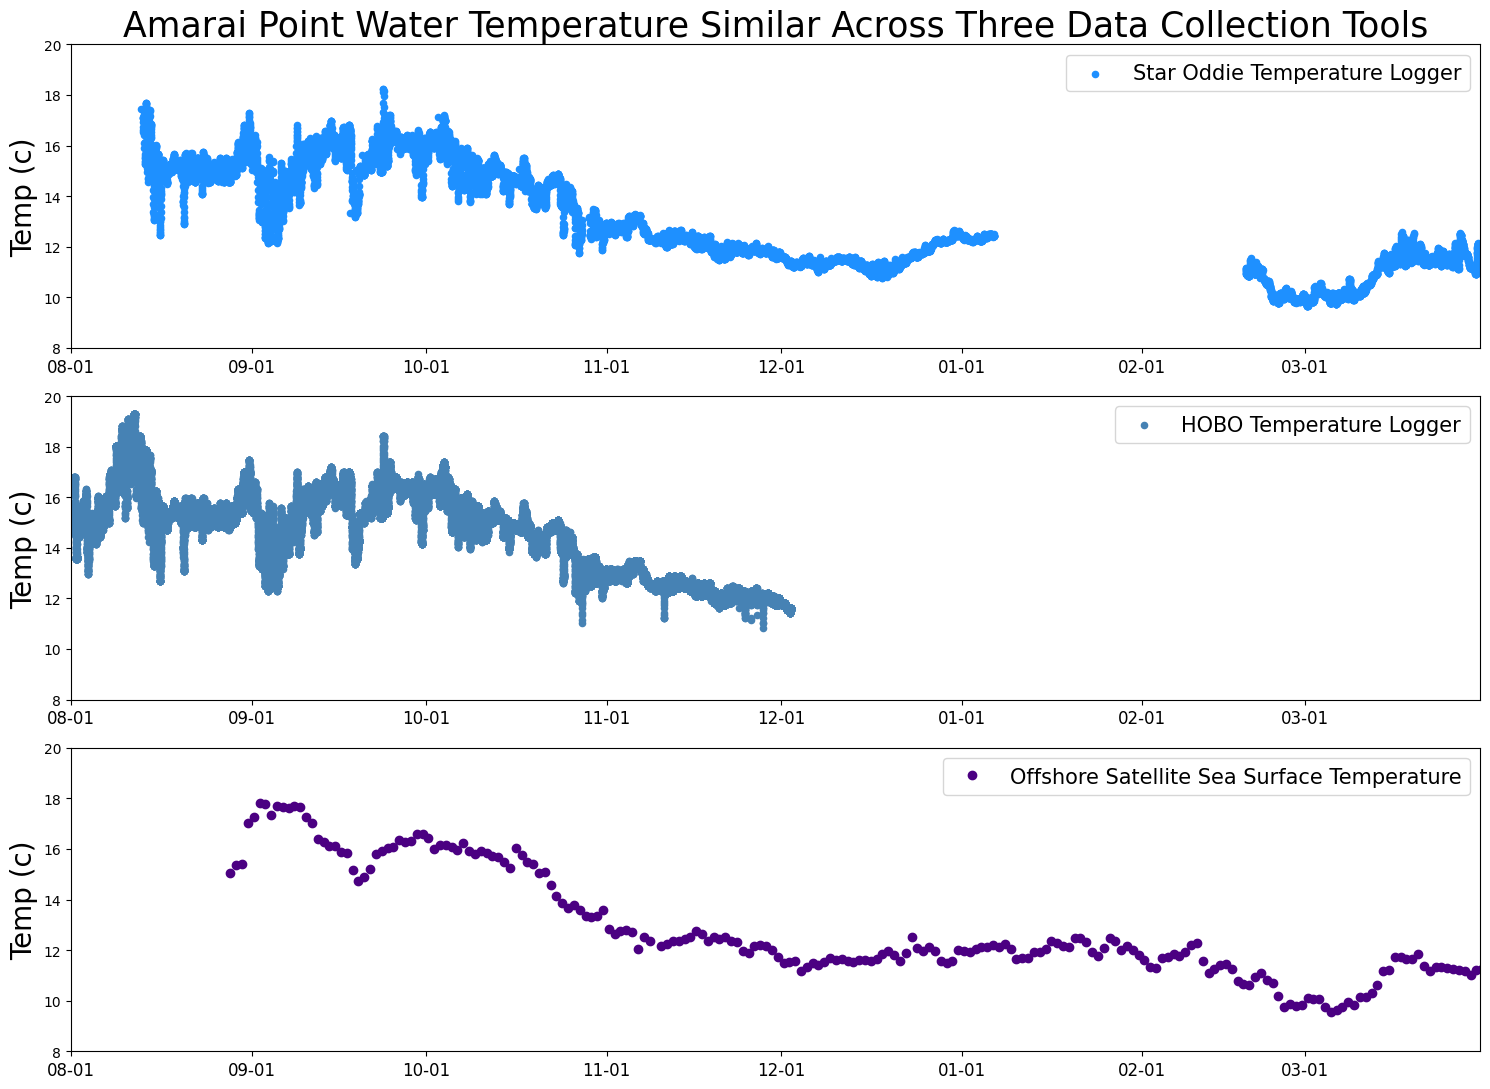

In [ ]:
start_date = '2022-08-01'
end_date = '2023-03-31'

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharey=False, figsize=(15, 11))

ax1.scatter(star_date, star_temp, color='dodgerblue', zorder=2, s=20)
ax1.set(ylabel='Temp (c)', title='Amarai Point Water Temperature Similar Across Three Data Collection Tools',
        xlim=(start_date, end_date), ylim=(8, 20))
ax1.set_title('Amarai Point Water Temperature Similar Across Three Data Collection Tools', fontsize=25)
ax1.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax1.legend(('Star Oddie Temperature Logger',), loc='best', fontsize=15)

ax2.scatter(hobo_date, hobo_temp, color='steelblue', zorder=2, s=20)
ax2.set(ylabel='Temp (c)', xlim=(start_date, end_date), ylim=(8, 20))
ax2.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax2.legend(('HOBO Temperature Logger',), loc='best', fontsize=15)

ax3.plot(ap_beach.time, ap_beach.mean(axis=(1, 2)), 'o', label='Amarai Point', zorder=2, color='indigo')
ax3.set(ylabel='Temp (c)', xlim=(start_date, end_date), ylim=(8, 20))
ax3.tick_params(axis='x', labelsize=12, labelbottom=True)
#ax3.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax3.legend(('Offshore Satellite Sea Surface Temperature',), loc='best', fontsize=15)

# Adjust label sizes
for ax in [ax1, ax2, ax3]:
    ax.xaxis.label.set_size(20)
    ax.yaxis.label.set_size(20)
    #ax.grid(False)
plt.tight_layout()
plt.show()


# Plotting salinty and rain

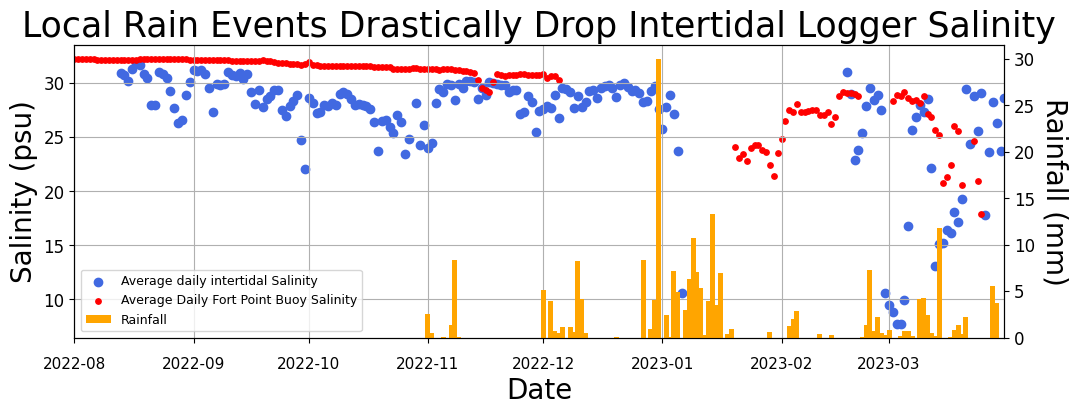

In [ ]:
f, (ax) = plt.subplots(figsize=(12,3.8))
ax.scatter(star_average['date_time'], star_average['salinity(ppt)'], color = 'royalblue', label = 'Average daily intertidal Salinity')
ax.set(xlabel = "Date", ylabel='Salinity (psu)')
ax.set_title('Local Rain Events Drastically Drop Intertidal Logger Salinity', fontsize =25)
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.tick_params(axis='x', labelsize=11, rotation= 0, labelbottom=True, direction= 'out', pad=10)
ax.tick_params(axis='y', labelsize=12)
#ax.xaxis.set_major_formatter(DateFormatter("%m-%d-%y"))
ax.set_xlim(start_date, end_date)
ax.grid(True)

ax2 = ax.twinx() #to plot a second y axis
ax2.bar(precip_date, precip_rain, width = 1.3, color = 'orange', label = 'Rainfall')
plt.ylabel('Rainfall (mm)', fontsize=12, rotation= 270, va="bottom")
#ax2.set(ylabel='Rainfall (mm)')
ax2.set_xlim(start_date, end_date)
ax2.tick_params(axis='y', labelsize=12)
ax2.yaxis.label.set_size(20)
ax2.grid(False)

#ax3 = ax.twinx()
ax.scatter(fp_average['date_time'], fp_average['salinity(ppt)'], color='red', s=15, label = 'Average Daily Fort Point Buoy Salinity')
ax.set_xlim(start_date, end_date)
#below code will show your legend for two y axis together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower left', fontsize = 9)